# Trabajo Práctico N°1 — Simulación y Procesos Estocásticos

**Alumnos: Chocobares Juan cruz - Formenti Agustín - Morenico Andrés - Mendes Lorenzo - Ancarani Juan Diego**


## Imports y configuración general

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
from scipy.stats import chi2, kstest, uniform
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3


---
## Punto 1 — Distribuciones estadísticas

A continuación se describen las siete distribuciones requeridas con sus fórmulas,
escenarios de aplicación y características principales.


### 1a) Distribución Uniforme (continua)

**Fórmula:**
$$f(x) = \frac{1}{b-a}, \quad a < x < b$$

**Función acumulada:**
$$F(x) = \frac{x-a}{b-a}, \quad a < x < b$$

**Parámetros:**
- Media: $E[X] = \dfrac{a+b}{2}$
- Varianza: $Var(X) = \dfrac{(b-a)^2}{12}$
- Discreta/continua: **continua**
- Moda: cualquier valor en $[a,b]$ (distribución plana)

**Escenarios de aplicación:**
- Modelado de cualquier evento en el que todos los resultados dentro de un intervalo son igualmente probables.
- Simulación de tiempos de llegada cuando no se conoce la distribución exacta (máxima incertidumbre).
- Generación de números pseudoaleatorios como base para otras distribuciones.
- Sorteos, ruletas, asignación aleatoria de recursos.


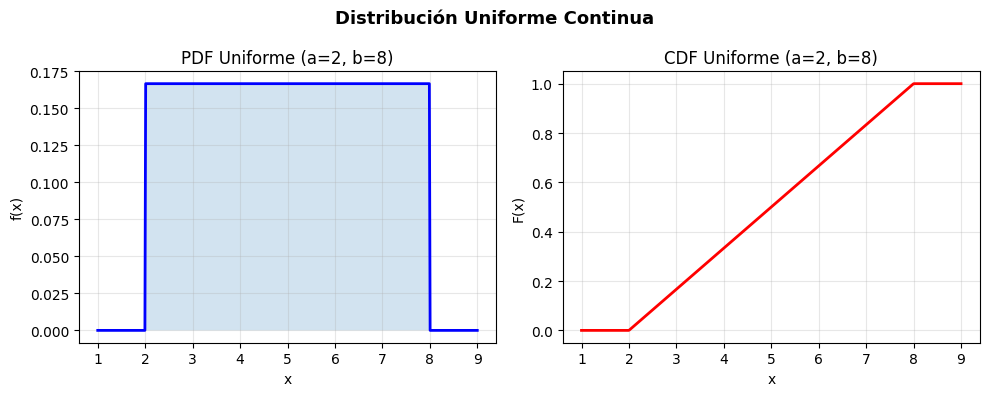

Media teórica: 5.0000
Varianza teórica: 3.0000


In [2]:
# Visualización de la PDF y CDF de la distribución uniforme continua
a, b = 2, 8
x = np.linspace(a - 1, b + 1, 500)
pdf = np.where((x >= a) & (x <= b), 1/(b-a), 0)
cdf = np.where(x < a, 0, np.where(x > b, 1, (x-a)/(b-a)))

fig, axes = plt.subplots(1, 2)
axes[0].plot(x, pdf, 'b-', lw=2)
axes[0].fill_between(x, pdf, alpha=0.2)
axes[0].set_title(f'PDF Uniforme (a={a}, b={b})')
axes[0].set_xlabel('x'); axes[0].set_ylabel('f(x)')

axes[1].plot(x, cdf, 'r-', lw=2)
axes[1].set_title(f'CDF Uniforme (a={a}, b={b})')
axes[1].set_xlabel('x'); axes[1].set_ylabel('F(x)')

plt.suptitle('Distribución Uniforme Continua', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

media = (a + b) / 2
varianza = (b - a)**2 / 12
print(f"Media teórica: {media:.4f}")
print(f"Varianza teórica: {varianza:.4f}")


### 1b) Distribución Triangular (continua)

**Fórmula:**
$$f(x) = \begin{cases}
\dfrac{2(x-a)}{(b-a)(c-a)} & a \leq x \leq c \\[6pt]
\dfrac{2(b-x)}{(b-a)(b-c)} & c < x \leq b \\[6pt]
0 & \text{resto}
\end{cases}$$

donde $a$ = mínimo, $b$ = máximo, $c$ = moda.

**Función acumulada:**
$$F(x) = \begin{cases}
0 & x < a \\
\dfrac{(x-a)^2}{(b-a)(c-a)} & a \leq x \leq c \\
1 - \dfrac{(b-x)^2}{(b-a)(b-c)} & c < x \leq b \\
1 & x > b
\end{cases}$$

**Parámetros:**
- Media: $E[X] = \dfrac{a + b + c}{3}$
- Varianza: $Var(X) = \dfrac{a^2 + b^2 + c^2 - ab - ac - bc}{18}$
- Discreta/continua: **continua**
- Moda: $c$

**Escenarios de aplicación:**
- Estimación de tiempos en gestión de proyectos (PERT) cuando se conoce el valor mínimo, máximo y más probable.
- Modelado de costos o duraciones en simulaciones cuando los datos son escasos.
- Usado en ingeniería y economía como distribución "de experto": se le pide al experto tres valores (pesimista, optimista, más probable).


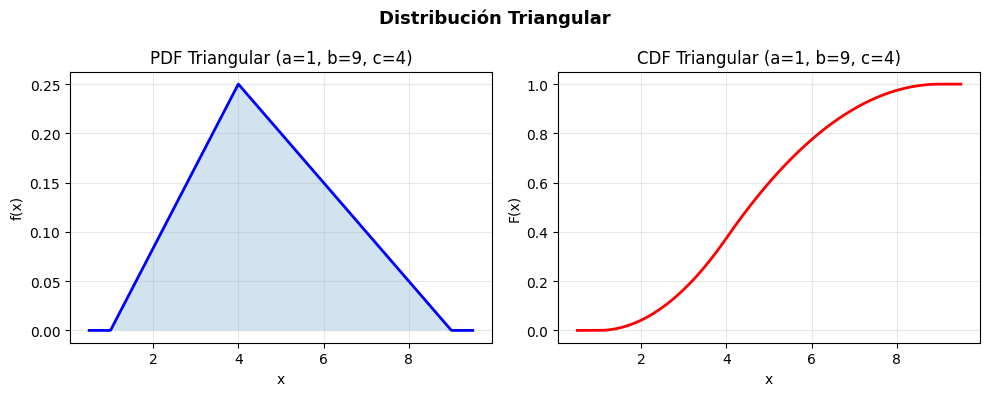

Media teórica: 4.6667
Varianza teórica: 2.7222


In [3]:
# Visualización de la PDF y CDF de la distribución triangular
from scipy.stats import triang

a, b, c = 1, 9, 4          # mínimo, máximo, moda
loc = a
scale = b - a
c_norm = (c - a) / (b - a) 

x = np.linspace(a - 0.5, b + 0.5, 500)
rv = triang(c_norm, loc=loc, scale=scale)

fig, axes = plt.subplots(1, 2)
axes[0].plot(x, rv.pdf(x), 'b-', lw=2)
axes[0].fill_between(x, rv.pdf(x), alpha=0.2)
axes[0].set_title(f'PDF Triangular (a={a}, b={b}, c={c})')
axes[0].set_xlabel('x'); axes[0].set_ylabel('f(x)')

axes[1].plot(x, rv.cdf(x), 'r-', lw=2)
axes[1].set_title(f'CDF Triangular (a={a}, b={b}, c={c})')
axes[1].set_xlabel('x'); axes[1].set_ylabel('F(x)')

plt.suptitle('Distribución Triangular', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

media = (a + b + c) / 3
varianza = (a**2 + b**2 + c**2 - a*b - a*c - b*c) / 18
print(f"Media teórica: {media:.4f}")
print(f"Varianza teórica: {varianza:.4f}")


### 1c) Distribución Exponencial (continua)

**Fórmula:**
$$f(x) = \lambda e^{-\lambda x}, \quad x \geq 0$$

**Función acumulada:**
$$F(x) = 1 - e^{-\lambda x}, \quad x \geq 0$$

**Parámetros:**
- Media: $E[X] = \dfrac{1}{\lambda}$
- Varianza: $Var(X) = \dfrac{1}{\lambda^2}$
- Discreta/continua: **continua**
- Moda: $0$
- Propiedad clave: **sin memoria** — $P(X > a+b \mid X > a) = P(X > b)$

**Escenarios de aplicación:**
- Tiempo entre llegadas de clientes a una cola (Proceso de Poisson).
- Tiempo de vida útil de componentes electrónicos o mecánicos.
- Tiempo entre llamadas en un call center.
- Tiempo hasta la próxima falla en un sistema de confiabilidad.


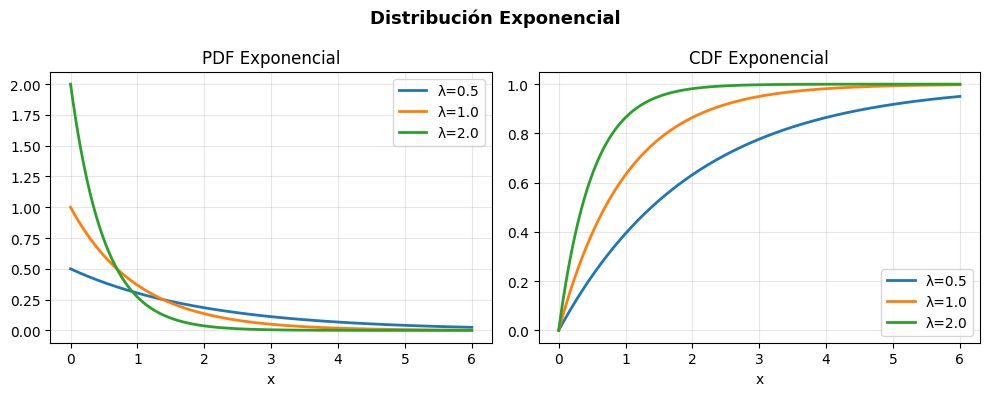

λ=1.0 → Media teórica: 1.0000 | Varianza teórica: 1.0000


In [4]:
# Visualización de la PDF y CDF de la distribución exponencial
lambdas = [0.5, 1.0, 2.0]
x = np.linspace(0, 6, 500)

fig, axes = plt.subplots(1, 2)
for lam in lambdas:
    pdf = lam * np.exp(-lam * x)
    cdf = 1 - np.exp(-lam * x)
    axes[0].plot(x, pdf, lw=2, label=f'λ={lam}')
    axes[1].plot(x, cdf, lw=2, label=f'λ={lam}')

axes[0].set_title('PDF Exponencial'); axes[0].set_xlabel('x'); axes[0].legend()
axes[1].set_title('CDF Exponencial'); axes[1].set_xlabel('x'); axes[1].legend()

plt.suptitle('Distribución Exponencial', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

lam = 1.0
print(f"λ={lam} → Media teórica: {1/lam:.4f} | Varianza teórica: {1/lam**2:.4f}")


### 1d) Distribución Bernoulli (discreta)

**Fórmula:**
$$P(X = k) = p^k (1-p)^{1-k}, \quad k \in \{0, 1\}$$

Es decir: $P(X=1) = p$ y $P(X=0) = 1-p$

**Parámetros:**
- Media: $E[X] = p$
- Varianza: $Var(X) = p(1-p)$
- Discreta/continua: **discreta**
- Moda: $1$ si $p > 0.5$; $0$ si $p < 0.5$; ambos si $p = 0.5$

**Escenarios de aplicación:**
- Resultado de un único experimento con dos posibles outcomes (éxito/fracaso).
- Lanzamiento de una moneda (cara/ceca).
- Resultado de un test de calidad (defectuoso/no defectuoso).
- Presencia o ausencia de un atributo en un individuo (enfermo/sano).

> **Nota:** La distribución Binomial es una suma de $n$ variables de Bernoulli independientes.


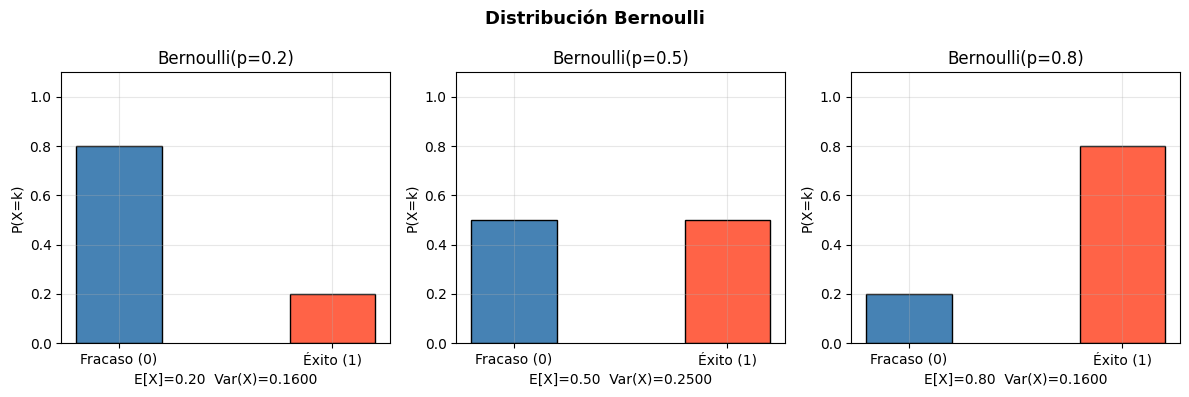

In [5]:
# Visualización de la distribución Bernoulli
ps = [0.2, 0.5, 0.8]
fig, axes = plt.subplots(1, len(ps), figsize=(12, 4))

for ax, p in zip(axes, ps):
    k = [0, 1]
    probs = [1 - p, p]
    ax.bar(k, probs, color=['steelblue', 'tomato'], width=0.4, edgecolor='black')
    ax.set_xticks([0, 1]); ax.set_xticklabels(['Fracaso (0)', 'Éxito (1)'])
    ax.set_ylim(0, 1.1); ax.set_title(f'Bernoulli(p={p})')
    ax.set_ylabel('P(X=k)')
    media = p; varianza = p * (1 - p)
    ax.set_xlabel(f'E[X]={media:.2f}  Var(X)={varianza:.4f}')

plt.suptitle('Distribución Bernoulli', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### 1e) Distribución Binomial (discreta)

**Fórmula:**
$$P(X = k) = \binom{n}{k} p^k (1-p)^{n-k}, \quad k = 0, 1, \ldots, n$$

**Parámetros:**
- Media: $E[X] = n \cdot p$
- Varianza: $Var(X) = n \cdot p \cdot (1-p)$
- Discreta/continua: **discreta**
- Moda: $\lfloor (n+1)p \rfloor$

**Escenarios de aplicación:**
- Número de productos defectuosos en un lote de $n$ unidades inspeccionadas.
- Número de clientes que aceptan una oferta de $n$ contactados.
- Número de caras al lanzar $n$ monedas.
- Cantidad de pacientes que responden a un tratamiento en un ensayo clínico de $n$ pacientes.

> **Relación con Bernoulli:** $X \sim Bin(n, p)$ es la suma de $n$ variables $Bernoulli(p)$ independientes.  
> **Relación con Poisson:** cuando $n \to \infty$ y $p \to 0$ con $\lambda = np$ fijo, $Bin(n,p) \approx Poisson(\lambda)$.


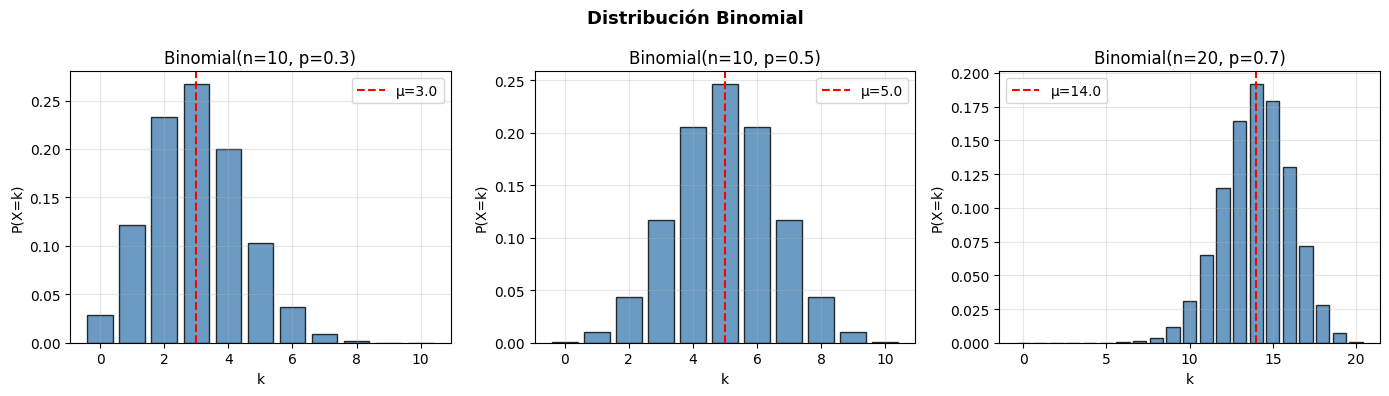

In [7]:
# Visualización de la distribución Binomial
configs = [(10, 0.3), (10, 0.5), (20, 0.7)]
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (n, p) in zip(axes, configs):
    k = np.arange(0, n + 1)
    probs = stats.binom.pmf(k, n, p)
    ax.bar(k, probs, color='steelblue', edgecolor='black', alpha=0.8)
    ax.set_title(f'Binomial(n={n}, p={p})')
    ax.set_xlabel('k'); ax.set_ylabel('P(X=k)')
    media = n * p; varianza = n * p * (1 - p)
    ax.axvline(media, color='red', linestyle='--', label=f'μ={media:.1f}')
    ax.legend()

plt.suptitle('Distribución Binomial', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### 1f) Distribución Poisson (discreta)

**Fórmula:**
$$P(X = k) = \frac{e^{-\lambda} \lambda^k}{k!}, \quad k = 0, 1, 2, \ldots$$

**Parámetros:**
- Media: $E[X] = \lambda$
- Varianza: $Var(X) = \lambda$
- Discreta/continua: **discreta**
- Moda: $\lfloor \lambda \rfloor$ (y también $\lambda - 1$ si $\lambda$ es entero)

**Escenarios de aplicación:**
- Número de llegadas a una cola en un intervalo de tiempo (Proceso de Poisson).
- Número de llamadas recibidas por un call center por hora.
- Número de accidentes de tráfico en una autopista por día.
- Número de mutaciones en una hebra de ADN.
- Número de errores tipográficos en una página.

> **Relación con Exponencial:** si los tiempos entre eventos son $Exp(\lambda)$, entonces el número de eventos en tiempo $t$ es $Poisson(\lambda t)$.


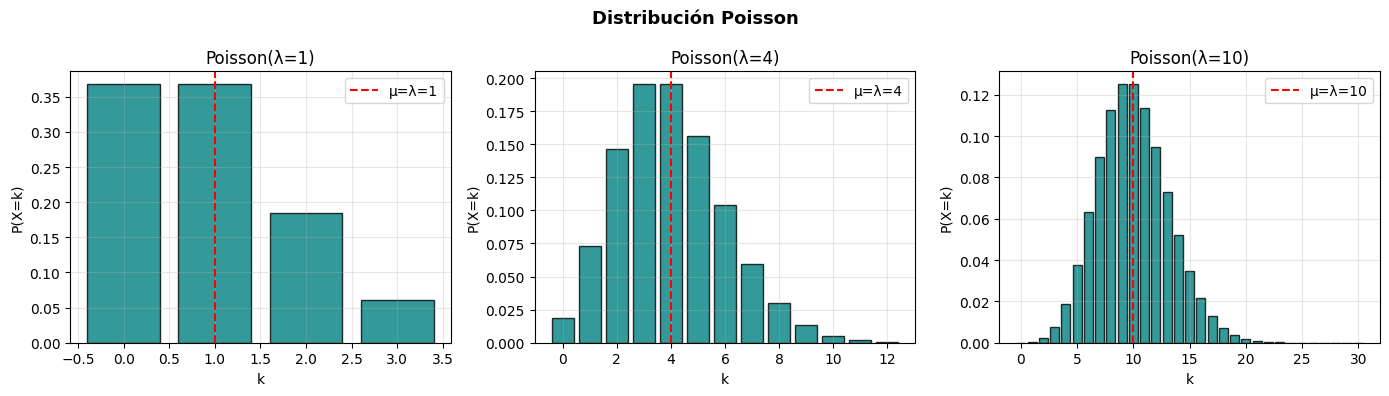

In [8]:
# Visualización de la distribución Poisson
lambdas = [1, 4, 10]
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, lam in zip(axes, lambdas):
    k = np.arange(0, int(lam * 3) + 1)
    probs = stats.poisson.pmf(k, lam)
    ax.bar(k, probs, color='teal', edgecolor='black', alpha=0.8)
    ax.set_title(f'Poisson(λ={lam})')
    ax.set_xlabel('k'); ax.set_ylabel('P(X=k)')
    ax.axvline(lam, color='red', linestyle='--', label=f'μ=λ={lam}')
    ax.legend()

plt.suptitle('Distribución Poisson', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### 1g) Distribución Normal (continua)

**Fórmula:**
$$f(x) = \frac{1}{\sqrt{2\pi}\,\sigma} \, e^{-\frac{(x-\mu)^2}{2\sigma^2}}$$

**Función acumulada:** no tiene forma cerrada; se tabula mediante la normal estándar $Z \sim N(0,1)$:
$$F(x) = \Phi\!\left(\frac{x - \mu}{\sigma}\right)$$

**Parámetros:**
- Media: $E[X] = \mu$
- Varianza: $Var(X) = \sigma^2$
- Discreta/continua: **continua**
- Moda: $\mu$ (simétrica)
- Regla empírica: 68% de los datos cae en $[\mu \pm \sigma]$, 95% en $[\mu \pm 2\sigma]$, 99.7% en $[\mu \pm 3\sigma]$

**Escenarios de aplicación:**
- Errores de medición en instrumentos.
- Alturas, pesos y otras características físicas de una población.
- Rendimiento académico de un grupo de estudiantes.
- Por el Teorema Central del Límite: suma de muchas variables aleatorias independientes converge a Normal.


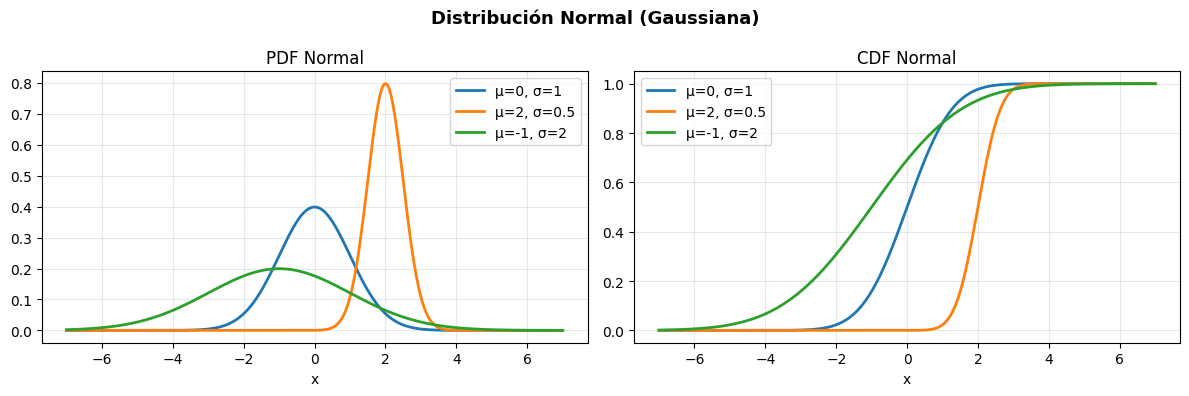

In [9]:
# Visualización de la distribución Normal
configs = [(0, 1), (2, 0.5), (-1, 2)]
x = np.linspace(-7, 7, 500)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for mu, sigma in configs:
    rv = stats.norm(mu, sigma)
    axes[0].plot(x, rv.pdf(x), lw=2, label=f'μ={mu}, σ={sigma}')
    axes[1].plot(x, rv.cdf(x), lw=2, label=f'μ={mu}, σ={sigma}')

axes[0].set_title('PDF Normal'); axes[0].set_xlabel('x'); axes[0].legend()
axes[1].set_title('CDF Normal'); axes[1].set_xlabel('x'); axes[1].legend()

plt.suptitle('Distribución Normal (Gaussiana)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


---
## Punto 2 — Métodos de generación de números aleatorios

En simulación se necesitan grandes cantidades de números pseudoaleatorios con
distribución uniforme en $[0,1]$. Los dos métodos clásicos son el **método de los
cuadrados medios** (von Neumann) y el **método congruencial lineal** (LCG).


### 2.1 Método de los Cuadrados Medios (Mid-Square — von Neumann)

**Fundamento:**
1. Se parte de una semilla $X_0$ de $d$ dígitos (típicamente $d=4$).
2. Se calcula $X_0^2$ y se escribe con $2d$ dígitos (rellenando con ceros a la izquierda si es necesario).
3. Se extraen los $d$ dígitos centrales → $X_1$.
4. Se repite el proceso con $X_1$, y así sucesivamente.
5. El número pseudoaleatorio en $[0,1)$ es $U_i = X_i / 10^d$.

**Ventajas:**
- Conceptualmente simple de entender e implementar.

**Desventajas:**
- Es un **mal generador**: sus propiedades estadísticas no están bien caracterizadas.
- Fuertemente dependiente de la semilla: con ciertas semillas entra en ciclos muy cortos o colapsa a 0 rápidamente (e.g., semilla 2100 → ciclo inmediato).
- Período corto y no predecible.
- No recomendado para uso en simulaciones serias.


In [10]:
def mid_square(semilla, n=20, d=4):
    """
    Generador de cuadrados medios (von Neumann).
    semilla : entero de d dígitos
    n       : cantidad de números a generar
    d       : cantidad de dígitos de la semilla
    """
    resultados = []
    x = semilla
    for _ in range(n):
        x_sq = x ** 2
        x_str = str(x_sq).zfill(2 * d)  
        inicio = (len(x_str) - d) // 2
        x = int(x_str[inicio: inicio + d])
        u = x / (10 ** d)
        resultados.append((x, u))
    return resultados

# Acá se prueban con las semillas del material de clase: 4010, 2100, 3792
semillas = [1234, 4010, 2100, 3792]

for s in semillas:
    print(f"\nSemilla: {s} ")
    resultados = mid_square(s, n=15)
    xs = [r[0] for r in resultados]
    us = [r[1] for r in resultados]
    print(f"  Secuencia X_i: {xs}")
    print(f"  U_i en [0,1):  {[round(u, 4) for u in us]}")



Semilla: 1234 
  Secuencia X_i: [5227, 3215, 3362, 3030, 1809, 2724, 4201, 6484, 422, 1780, 1684, 8358, 8561, 2907, 4506]
  U_i en [0,1):  [0.5227, 0.3215, 0.3362, 0.303, 0.1809, 0.2724, 0.4201, 0.6484, 0.0422, 0.178, 0.1684, 0.8358, 0.8561, 0.2907, 0.4506]

Semilla: 4010 
  Secuencia X_i: [801, 6416, 1650, 7225, 2006, 240, 576, 3317, 24, 5, 0, 0, 0, 0, 0]
  U_i en [0,1):  [0.0801, 0.6416, 0.165, 0.7225, 0.2006, 0.024, 0.0576, 0.3317, 0.0024, 0.0005, 0.0, 0.0, 0.0, 0.0, 0.0]

Semilla: 2100 
  Secuencia X_i: [4100, 8100, 6100, 2100, 4100, 8100, 6100, 2100, 4100, 8100, 6100, 2100, 4100, 8100, 6100]
  U_i en [0,1):  [0.41, 0.81, 0.61, 0.21, 0.41, 0.81, 0.61, 0.21, 0.41, 0.81, 0.61, 0.21, 0.41, 0.81, 0.61]

Semilla: 3792 
  Secuencia X_i: [3792, 3792, 3792, 3792, 3792, 3792, 3792, 3792, 3792, 3792, 3792, 3792, 3792, 3792, 3792]
  U_i en [0,1):  [0.3792, 0.3792, 0.3792, 0.3792, 0.3792, 0.3792, 0.3792, 0.3792, 0.3792, 0.3792, 0.3792, 0.3792, 0.3792, 0.3792, 0.3792]


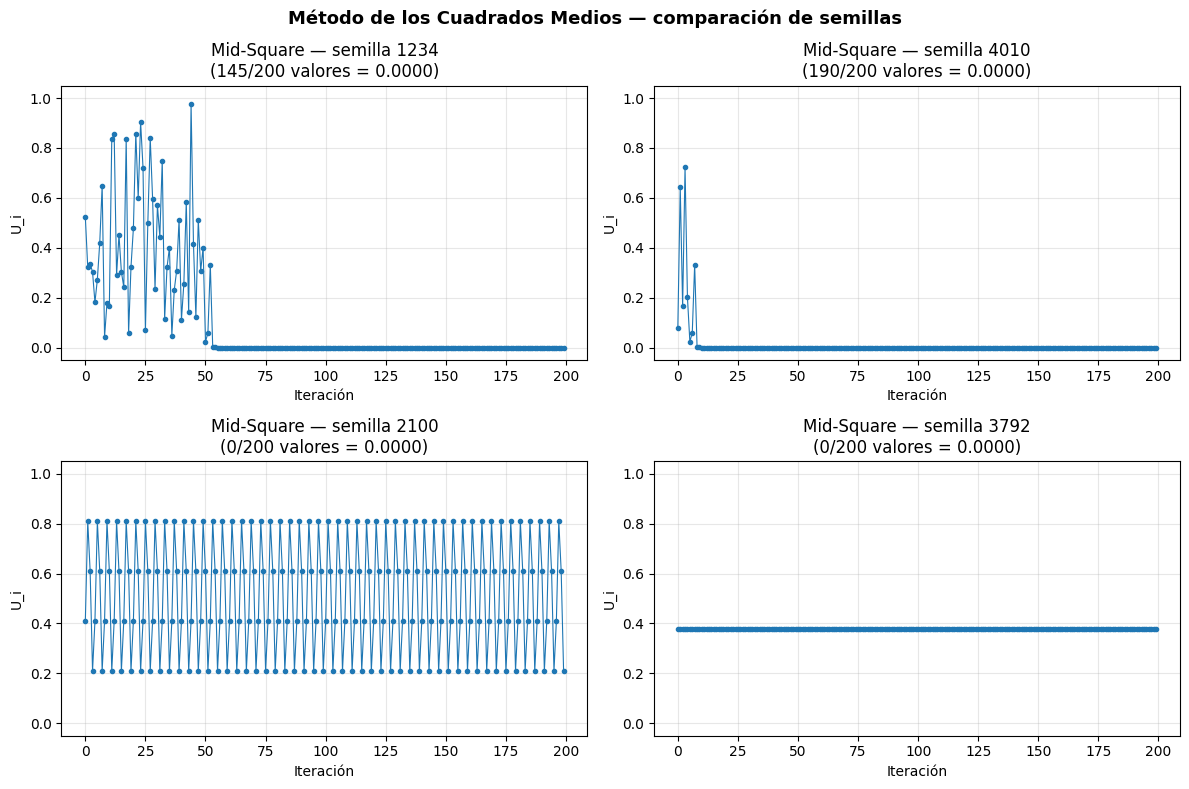

In [11]:
# Visualizar la calidad del mid-square comparando semillas
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for idx, s in enumerate(semillas):
    resultados = mid_square(s, n=200)
    us = [r[1] for r in resultados]
    # detectar si colapsó a 0
    ceros = sum(1 for u in us if u == 0)
    axes[idx].plot(us, 'o-', markersize=3, lw=0.8)
    axes[idx].set_title(f'Mid-Square — semilla {s}\n({ceros}/200 valores = 0.0000)')
    axes[idx].set_xlabel('Iteración'); axes[idx].set_ylabel('U_i')
    axes[idx].set_ylim(-0.05, 1.05)

plt.suptitle('Método de los Cuadrados Medios — comparación de semillas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### 2.2 Método Congruencial Lineal (LCG)

**Fundamento:**

La idea central es generar una secuencia de enteros mediante la recurrencia:

$$y_n = (a \cdot y_{n-1} + c) \mod M$$

donde:
- $a$: multiplicador
- $c$: incremento  
- $M$: módulo (determina el rango máximo de la secuencia)
- $y_0$: semilla inicial

Los números pseudoaleatorios en $[0,1)$ se obtienen como $U_i = y_i / M$.

**Período:** la secuencia se repite con período $K \leq M$. Para maximizar el período se usan criterios matemáticos (teorema de Hull-Dobell).

**Parámetros clásicos del material de clase:**
- Lewis-Learmonth: $M = 2^{31}-1$, $a = 7^5 = 16807$, $c = 0$
- RANDU: $M = 2^{31}$, $a = 2^{16}+3$, $c = 0$ (deficiente en dimensiones altas)

**Ventajas:**
- Rápido y eficiente computacionalmente.
- Período largo y bien estudiado con la elección correcta de parámetros.
- Propiedades estadísticas conocidas y analizables.

**Desventajas:**
- Los puntos en $k$ dimensiones caen en hiperplanos (estructura lattice).
- No es criptográficamente seguro.
- La elección incorrecta de parámetros produce secuencias de mala calidad (RANDU).


In [12]:
def lcg(semilla, a, c, M, n=1000):
    """
    Generador Congruencial Lineal (LCG).
    y_n = (a * y_{n-1} + c) mod M
    Retorna lista de U_i = y_i / M en [0,1)
    """
    y = semilla
    resultados = []
    for _ in range(n):
        y = (a * y + c) % M
        resultados.append(y / M)
    return resultados

# Parámetros de referencia del material de clase
# Lewis-Learmonth
M_LL  = 2**31 - 1
a_LL  = 7**5          
c_LL  = 0
semilla = 12345

us_LL = lcg(semilla, a_LL, c_LL, M_LL, n=10000)

print("Lewis-Learmonth (M=2^31-1, a=16807, c=0)")
print(f"  Primeros 10 valores: {[round(u, 6) for u in us_LL[:10]]}")
print(f"  Media muestral:    {np.mean(us_LL):.6f}  (esperada: 0.5000)")
print(f"  Varianza muestral: {np.var(us_LL):.6f}  (esperada: {1/12:.6f})")


Lewis-Learmonth (M=2^31-1, a=16807, c=0)
  Primeros 10 valores: [0.096617, 0.833995, 0.947702, 0.035879, 0.011546, 0.051155, 0.765787, 0.58493, 0.91413, 0.7838]
  Media muestral:    0.502620  (esperada: 0.5000)
  Varianza muestral: 0.083628  (esperada: 0.083333)


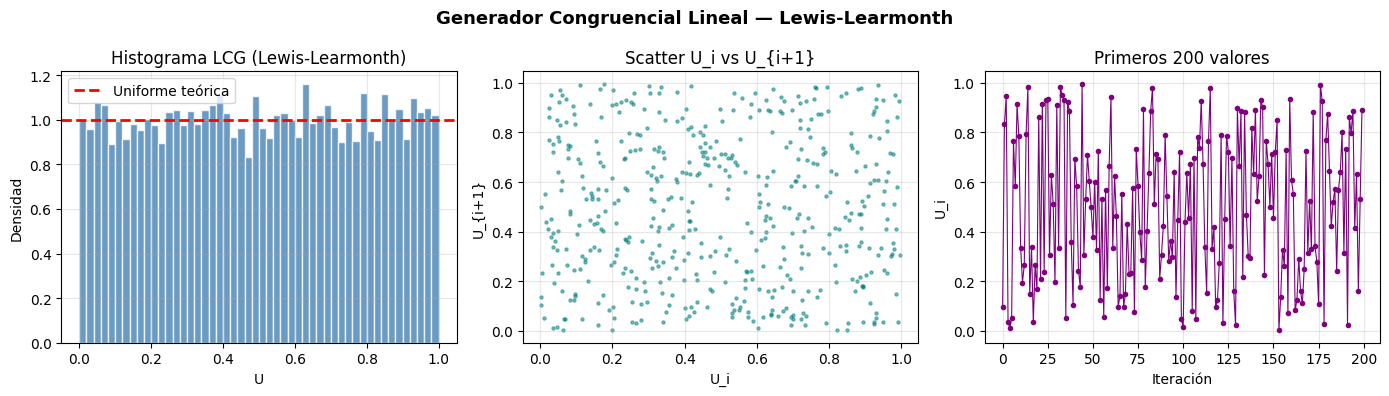

In [13]:
# Visualizar distribución del LCG
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Histograma
axes[0].hist(us_LL, bins=50, density=True, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axhline(1.0, color='red', lw=2, linestyle='--', label='Uniforme teórica')
axes[0].set_title('Histograma LCG (Lewis-Learmonth)')
axes[0].set_xlabel('U'); axes[0].set_ylabel('Densidad'); axes[0].legend()

# Gráfico de dispersión U_i vs U_{i+1} (test visual de independencia)
axes[1].scatter(us_LL[:500], us_LL[1:501], s=5, alpha=0.5, color='teal')
axes[1].set_title('Scatter U_i vs U_{i+1}')
axes[1].set_xlabel('U_i'); axes[1].set_ylabel('U_{i+1}')

# Serie temporal
axes[2].plot(us_LL[:200], 'o-', markersize=3, lw=0.8, color='purple')
axes[2].set_title('Primeros 200 valores')
axes[2].set_xlabel('Iteración'); axes[2].set_ylabel('U_i')

plt.suptitle('Generador Congruencial Lineal — Lewis-Learmonth', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### 2.3 Ejemplo numérico del LCG paso a paso

El siguiente ejemplo, tomado directamente del material de referencia de la cátedra, 
ilustra el funcionamiento del LCG con parámetros pequeños para seguirlo a mano:

**Parámetros:** $a = 17$, $c = 43$, $m = 100$, $X_0 = 27$

La recurrencia es: $X_{i+1} = (17 \cdot X_i + 43) \mod 100$

| $i$ | $X_i$ | $R_i = X_i / m$ |
|-----|--------|-----------------|
| 0   | 27     | —               |
| 1   | 2      | 0.02            |
| 2   | 77     | 0.77            |
| 3   | 52     | 0.52            |
| ... | ...    | ...             |

**Verificación manual:**
- $X_1 = (17 \times 27 + 43) \mod 100 = (459 + 43) \mod 100 = 502 \mod 100 = 2$
- $X_2 = (17 \times 2 + 43) \mod 100 = (34 + 43) \mod 100 = 77$
- $X_3 = (17 \times 77 + 43) \mod 100 = (1309 + 43) \mod 100 = 1352 \mod 100 = 52$

Notar que con $m = 100$ los números $R_i$ solo pueden tomar 100 valores distintos 
($0.00, 0.01, \ldots, 0.99$), lo que genera una distribución **discreta** en lugar de 
continua. Esto mejora enormemente al usar módulos grandes como $M = 2^{31}-1$.


In [14]:
# Ejemplo numérico del LCG con parámetros del material que vimos en clase: a=17, c=43, m=100, X0=27

def lcg_tabla(X0, a, c, m, n=15):
    """Genera una tabla paso a paso del LCG para verificar a mano."""
    X = X0
    print(f"Parámetros: a={a}, c={c}, m={m}, X0={X0}")
    print(f"Fórmula: X_{{i+1}} = ({a} * X_i + {c}) mod {m}")
    print("-" * 55)
    print(f"{'i':>4} | {'X_i':>8} | {'Cálculo':>25} | {'R_i':>8}")
    print("-" * 55)
    print(f"{'0':>4} | {X:>8} | {'(semilla)':>25} | {'—':>8}")
    
    resultados = []
    for i in range(1, n + 1):
        calculo = a * X + c
        X_nuevo = calculo % m
        R = X_nuevo / m
        print(f"{i:>4} | {X_nuevo:>8} | ({a}×{X}+{c})={calculo} mod {m} | {R:>8.2f}")
        X = X_nuevo
        resultados.append((i, X, R))
    return resultados

resultados = lcg_tabla(X0=27, a=17, c=43, m=100, n=10)


Parámetros: a=17, c=43, m=100, X0=27
Fórmula: X_{i+1} = (17 * X_i + 43) mod 100
-------------------------------------------------------
   i |      X_i |                   Cálculo |      R_i
-------------------------------------------------------
   0 |       27 |                 (semilla) |        —
   1 |        2 | (17×27+43)=502 mod 100 |     0.02
   2 |       77 | (17×2+43)=77 mod 100 |     0.77
   3 |       52 | (17×77+43)=1352 mod 100 |     0.52
   4 |       27 | (17×52+43)=927 mod 100 |     0.27
   5 |        2 | (17×27+43)=502 mod 100 |     0.02
   6 |       77 | (17×2+43)=77 mod 100 |     0.77
   7 |       52 | (17×77+43)=1352 mod 100 |     0.52
   8 |       27 | (17×52+43)=927 mod 100 |     0.27
   9 |        2 | (17×27+43)=502 mod 100 |     0.02
  10 |       77 | (17×2+43)=77 mod 100 |     0.77


---
## Punto 3 — Variantes del método congruencial

La fórmula general del LCG es $y_n = (a \cdot y_{n-1} + c) \mod M$.
Según los valores de $a$ y $c$ se obtienen tres variantes:

| Variante | Condición | Nombre |
|---|---|---|
| $c \neq 0$ | Caso general | **Mixto** |
| $c = 0$ | Solo multiplicación | **Multiplicativo** |
| $a = 1$ | Solo suma | **Aditivo** |


### 3.1 Congruencial Multiplicativo

$$y_n = a \cdot y_{n-1} \mod M$$

**Ventajas:** más rápido que el mixto (una operación menos por iteración). Período máximo posible = $M-1$ con la elección correcta de $a$.  
**Desventajas:** la semilla $y_0 = 0$ produce la secuencia $0, 0, 0, \ldots$ — debe evitarse. Período menor al mixto en general.

### 3.2 Congruencial Aditivo

$$y_n = (y_{n-1} + c) \mod M$$

(equivalente a $a = 1$)

**Ventajas:** implementación trivial, muy rápido.  
**Desventajas:** secuencia muy predecible y con baja aleatoriedad. Período máximo = $M / \text{mcd}(c, M)$. No recomendado para simulación.

### 3.3 Congruencial Mixto (o Lineal completo)

$$y_n = (a \cdot y_{n-1} + c) \mod M, \quad c \neq 0$$

**Ventajas:** puede alcanzar período completo $M$ bajo condiciones del Teorema de Hull-Dobell. Es el más versátil.  
**Desventajas:** levemente más lento que el multiplicativo por el sumando $c$.

### ¿Por qué necesitamos tests de verificación?

Aunque estos métodos son **deterministas** (dada la misma semilla, producen la misma secuencia), deben *comportarse* como si fueran aleatorios para ser útiles en simulación. Los problemas más comunes son:
- Números no uniformemente distribuidos.
- Correlación entre valores consecutivos (falta de independencia).
- Media o varianza incorrectas.
- Período corto (variaciones cíclicas detectables).

Los tests estadísticos permiten verificar objetivamente si una secuencia cumple las propiedades deseadas, ya que estos defectos **no son siempre visibles a simple vista**.


In [16]:
# Implementación de las tres variantes del generador congruencial: multiplicativo, aditivo y mixto

def congruencial_multiplicativo(semilla, a, M, n=1000):
    """y_n = a * y_{n-1} mod M  (c=0). Semilla != 0."""
    assert semilla != 0, "La semilla no puede ser 0 en el método multiplicativo"
    y = semilla
    out = []
    for _ in range(n):
        y = (a * y) % M
        out.append(y / M)
    return out

def congruencial_aditivo(semilla, c, M, n=1000):
    """y_n = (y_{n-1} + c) mod M  (a=1)."""
    y = semilla
    out = []
    for _ in range(n):
        y = (y + c) % M
        out.append(y / M)
    return out

def congruencial_mixto(semilla, a, c, M, n=1000):
    """y_n = (a * y_{n-1} + c) mod M  (caso general)."""
    y = semilla
    out = []
    for _ in range(n):
        y = (a * y + c) % M
        out.append(y / M)
    return out

# Parámetros 
M   = 2**31 - 1          # módulo grande (Lewis-Learmonth)
a   = 16807              # multiplicador (7^5)
c   = 12345              # incremento para mixto y aditivo
s0  = 54321              # semilla
N   = 5000

us_mult = congruencial_multiplicativo(s0, a, M, N)
us_adic = congruencial_aditivo(s0, c, M, N)
us_mix  = congruencial_mixto(s0, a, c, M, N)

# Comparación de estadísticas entre los tres métodos y la distribución uniforme teórica
print(f"{'Método':<20} {'Media':>10} {'Varianza':>12} {'Min':>8} {'Max':>8}")
print("-" * 60)
for nombre, us in [("Multiplicativo", us_mult), ("Aditivo", us_adic), ("Mixto", us_mix)]:
    print(f"{nombre:<20} {np.mean(us):>10.6f} {np.var(us):>12.8f} {min(us):>8.4f} {max(us):>8.4f}")
print(f"\n{'Teórico (U[0,1])':<20} {'0.500000':>10} {'0.08333333':>12}")


Método                    Media     Varianza      Min      Max
------------------------------------------------------------
Multiplicativo         0.492397   0.08185180   0.0001   0.9997
Aditivo                0.014400   0.00006885   0.0000   0.0288
Mixto                  0.504911   0.08350802   0.0002   0.9997

Teórico (U[0,1])       0.500000   0.08333333


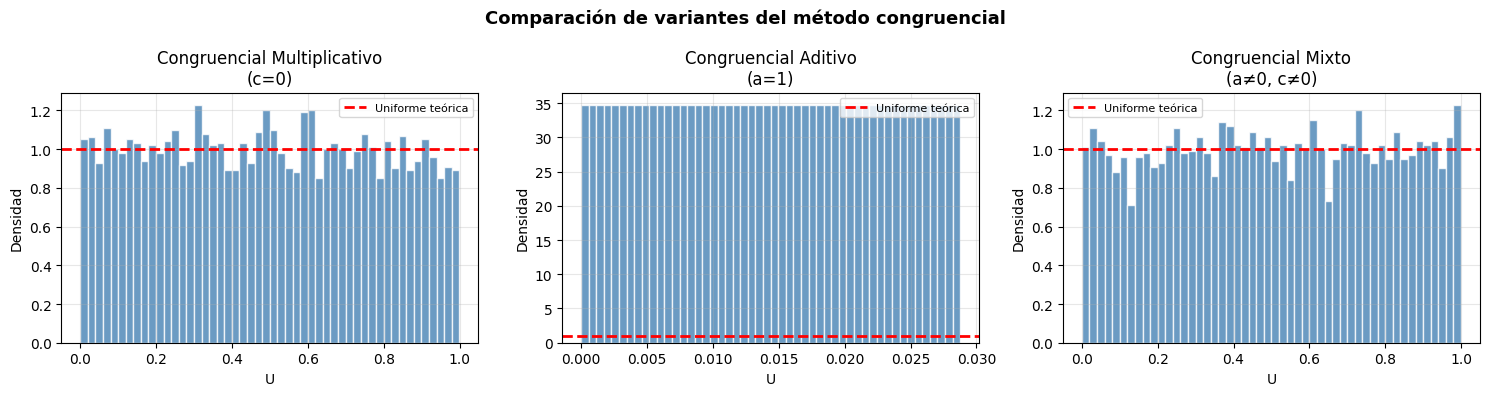

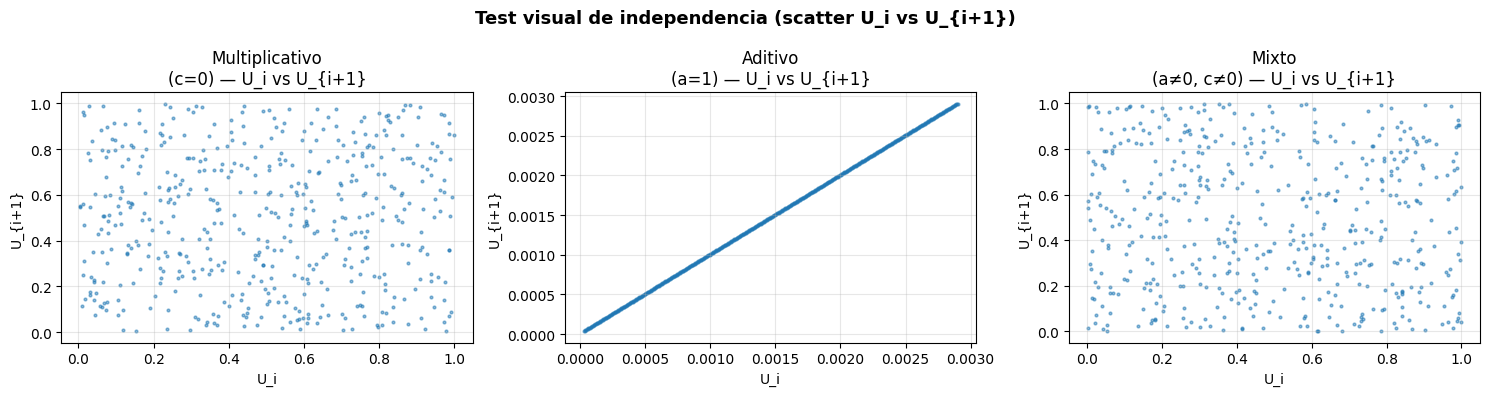

In [17]:
# Histogramas comparativos de las tres variantes
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
metodos = [("Multiplicativo\n(c=0)", us_mult),
           ("Aditivo\n(a=1)", us_adic),
           ("Mixto\n(a≠0, c≠0)", us_mix)]

for ax, (nombre, us) in zip(axes, metodos):
    ax.hist(us, bins=50, density=True, color='steelblue', edgecolor='white', alpha=0.8)
    ax.axhline(1.0, color='red', lw=2, linestyle='--', label='Uniforme teórica')
    ax.set_title(f'Congruencial {nombre}')
    ax.set_xlabel('U'); ax.set_ylabel('Densidad')
    ax.legend(fontsize=8)

plt.suptitle('Comparación de variantes del método congruencial', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Scatter para ver independencia
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (nombre, us) in zip(axes, metodos):
    ax.scatter(us[:500], us[1:501], s=4, alpha=0.5)
    ax.set_title(f'{nombre} — U_i vs U_{{i+1}}')
    ax.set_xlabel('U_i'); ax.set_ylabel('U_{i+1}')

plt.suptitle('Test visual de independencia (scatter U_i vs U_{i+1})', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


---
## Punto 4 — Pruebas de aleatoriedad

Para que una secuencia sea útil en simulación debe verificar dos propiedades fundamentales:
1. **Uniformidad:** los valores deben estar uniformemente distribuidos en $[0,1]$.
2. **Independencia:** los valores deben ser estadísticamente independientes entre sí.

A continuación se describen e implementan las principales pruebas.


### 4.1 Prueba de Uniformidad (Chi-cuadrado)

**Descripción:** divide el intervalo $[0,1]$ en $k$ subintervalos iguales y compara las frecuencias
observadas con las esperadas bajo uniformidad.

**Estadístico:**
$$\chi^2 = \sum_{i=1}^{k} \frac{(O_i - E_i)^2}{E_i}$$

donde $O_i$ = frecuencia observada en el intervalo $i$, $E_i = N/k$ = frecuencia esperada.

**Criterio:** si $\chi^2 < \chi^2_{\alpha, k-1}$ (valor crítico con $k-1$ grados de libertad y nivel de significancia $\alpha$), no se rechaza la hipótesis de uniformidad.

**Propiedad verificada:** que los números estén uniformemente distribuidos en $[0,1]$.


In [19]:
def prueba_chi2_uniformidad(us, k=10, alpha=0.05):
    """
    Prueba Chi-cuadrado de uniformidad.
    us    : secuencia de números en [0,1)
    k     : número de subintervalos
    alpha : nivel de significancia
    """
    N = len(us)
    E = N / k  # frecuencia esperada por intervalo
    # Contar frecuencias observadas
    obs, _ = np.histogram(us, bins=k, range=(0, 1))
    chi2_stat = np.sum((obs - E)**2 / E)
    chi2_crit = chi2.ppf(1 - alpha, df=k - 1)
    p_valor = 1 - chi2.cdf(chi2_stat, df=k - 1)
    rechaza = chi2_stat > chi2_crit
    return chi2_stat, chi2_crit, p_valor, rechaza, obs, E

# Acá aplicamos la prueba de chi-cuadrado a las tres secuencias generadas por los métodos congruenciales
secuencias = [("Multiplicativo", us_mult), ("Aditivo", us_adic), ("Mixto", us_mix)]
k = 10

print(f"{'Método':<18} {'χ² estadístico':>16} {'χ² crítico (α=0.05)':>20} {'p-valor':>10} {'¿Rechaza?':>12}")
print("-" * 80)
for nombre, us in secuencias:
    stat, crit, pval, rec, obs, E = prueba_chi2_uniformidad(us, k=k)
    print(f"{nombre:<18} {stat:>16.4f} {crit:>20.4f} {pval:>10.4f} {'SÍ ✗' if rec else 'NO ✓':>12}")


Método               χ² estadístico  χ² crítico (α=0.05)    p-valor    ¿Rechaza?
--------------------------------------------------------------------------------
Multiplicativo               5.9840              16.9190     0.7415         NO ✓
Aditivo                  45000.0000              16.9190     0.0000         SÍ ✗
Mixto                        8.5240              16.9190     0.4823         NO ✓


### 4.2 Prueba de Kolmogorov-Smirnov (KS)

**Descripción:** mide la máxima distancia entre la función de distribución empírica $F_n(x)$
y la CDF teórica (en este caso, la uniforme $F(x) = x$):

$$D_n = \sup_x |F_n(x) - F(x)|$$

**Criterio:** se rechaza la hipótesis de uniformidad si $D_n > D_{\alpha, n}$ (valor crítico tabulado).

**Ventaja sobre Chi-cuadrado:** no requiere agrupar en intervalos; trabaja con la distribución continua directamente.

**Propiedad verificada:** ajuste global a la distribución uniforme.


In [21]:
def prueba_ks(us, alpha=0.05):
    """Prueba Kolmogorov-Smirnov contra U[0,1]."""
    stat, p_valor = kstest(us, 'uniform')
    n = len(us)
    crit = 1.36 / np.sqrt(n)
    rechaza = stat > crit
    return stat, crit, p_valor, rechaza

print(f"{'Método':<18} {'D estadístico':>14} {'D crítico (α=0.05)':>20} {'p-valor':>10} {'Rechaza?':>12}")
print("-" * 76)
for nombre, us in secuencias:
    stat, crit, pval, rec = prueba_ks(us)
    print(f"{nombre:<18} {stat:>14.6f} {crit:>20.6f} {pval:>10.4f} {'SÍ ' if rec else 'NO ':>12}")


Método              D estadístico   D crítico (α=0.05)    p-valor     Rechaza?
----------------------------------------------------------------------------
Multiplicativo           0.016561             0.019233     0.1273          NO 
Aditivo                  0.971232             0.019233     0.0000          SÍ 
Mixto                    0.012056             0.019233     0.4580          NO 


### 4.3 Prueba de Independencia — Autocorrelación

**Descripción:** calcula la correlación entre $U_i$ y $U_{i+h}$ para distintos desfasajes $h$ (lags).
Si los valores son independientes, las autocorrelaciones deben estar cerca de cero.

**Estadístico:** coeficiente de autocorrelación muestral $\hat{\rho}(h)$.

**Criterio:** los valores deben estar dentro de la banda $\pm 1.96/\sqrt{N}$ para $\alpha = 0.05$.

**Propiedad verificada:** independencia entre valores de la secuencia.


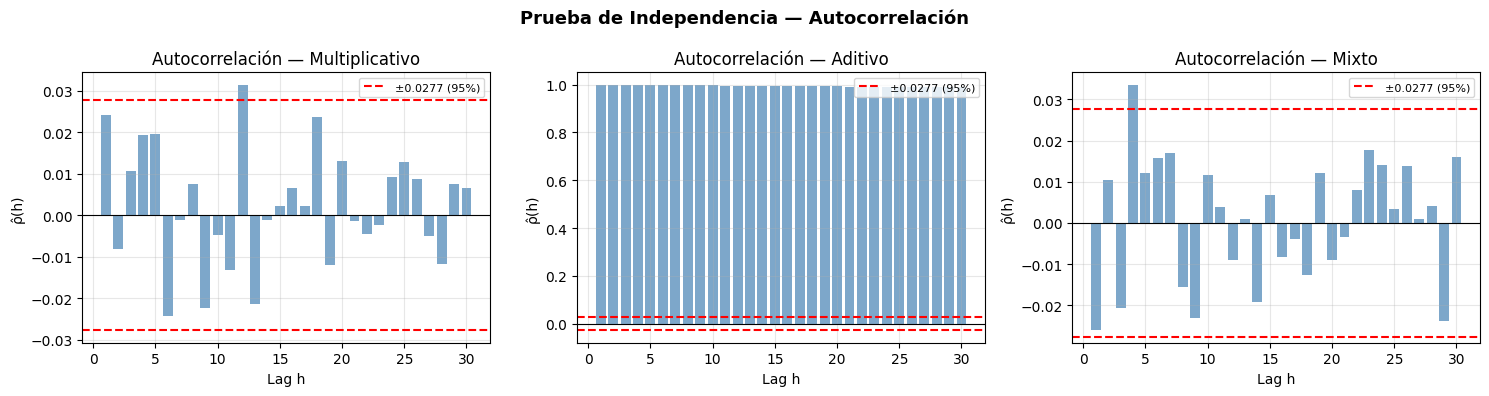

In [22]:
def prueba_autocorrelacion(us, max_lag=20, alpha=0.05):
    """Calcula autocorrelaciones para lags 1..max_lag."""
    N = len(us)
    u = np.array(us)
    u_mean = np.mean(u)
    u_var = np.var(u)
    acf = []
    for h in range(1, max_lag + 1):
        cov = np.mean((u[:N-h] - u_mean) * (u[h:] - u_mean))
        acf.append(cov / u_var)
    banda = 1.96 / np.sqrt(N)
    return np.array(acf), banda

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (nombre, us) in zip(axes, secuencias):
    acf, banda = prueba_autocorrelacion(us, max_lag=30)
    lags = np.arange(1, len(acf) + 1)
    ax.bar(lags, acf, color='steelblue', alpha=0.7)
    ax.axhline(banda,  color='red', linestyle='--', lw=1.5, label=f'±{banda:.4f} (95%)')
    ax.axhline(-banda, color='red', linestyle='--', lw=1.5)
    ax.axhline(0, color='black', lw=0.8)
    ax.set_title(f'Autocorrelación — {nombre}')
    ax.set_xlabel('Lag h'); ax.set_ylabel('ρ̂(h)')
    ax.legend(fontsize=8)

plt.suptitle('Prueba de Independencia — Autocorrelación', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### 4.4 Prueba de la Corrida (Runs Test)

**Descripción:** una *corrida* es una secuencia ininterrumpida de valores consecutivos
que están todos por encima o todos por debajo de la mediana (0.5).
Se cuenta el número total de corridas $R$ y se compara con el esperado bajo independencia.

**Estadístico (para muestras grandes):**
$$Z = \frac{R - \mu_R}{\sigma_R}$$

donde $\mu_R = \dfrac{2 n_1 n_2}{n_1 + n_2} + 1$ y 
$\sigma_R^2 = \dfrac{2 n_1 n_2 (2 n_1 n_2 - n_1 - n_2)}{(n_1+n_2)^2 (n_1+n_2-1)}$

con $n_1$ = cantidad de valores $> 0.5$ y $n_2$ = cantidad de valores $\leq 0.5$.

**Criterio:** se rechaza la hipótesis de independencia si $|Z| > z_{\alpha/2}$ (e.g., $1.96$ para $\alpha=0.05$).

**Propiedad verificada:** aleatoriedad e independencia (detecta tendencias o alternancia sistemática).


In [23]:
def prueba_corridas(us, alpha=0.05):
    """
    Prueba de la corrida (runs test) respecto a la mediana 0.5.
    """
    u = np.array(us)
    # Acá clasificamos cada valor como 1 (>0.5) o 0 (<=0.5)
    signos = (u > 0.5).astype(int)
    n1 = np.sum(signos == 1)
    n2 = np.sum(signos == 0)
    N  = n1 + n2
    # Contamos el número de corridas: una corrida es un cambio de signo (de 0 a 1 o de 1 a 0)
    R = 1 + np.sum(signos[:-1] != signos[1:])
    mu_R    = (2 * n1 * n2) / N + 1
    sigma2_R = (2 * n1 * n2 * (2 * n1 * n2 - N)) / (N**2 * (N - 1))
    sigma_R  = np.sqrt(sigma2_R)
    Z = (R - mu_R) / sigma_R
    z_crit = 1.96
    rechaza = abs(Z) > z_crit
    return R, mu_R, Z, z_crit, rechaza

print(f"{'Método':<18} {'Corridas R':>12} {'E[R]':>10} {'Z':>10} {'|Z|>1.96':>12} {'Rechaza?':>12}")
print("-" * 78)
for nombre, us in secuencias:
    R, mu_R, Z, z_crit, rec = prueba_corridas(us)
    print(f"{nombre:<18} {R:>12.0f} {mu_R:>10.2f} {Z:>10.4f} {abs(Z):>12.4f} {'SÍ' if rec else 'NO':>12}")


Método               Corridas R       E[R]          Z     |Z|>1.96     Rechaza?
------------------------------------------------------------------------------
Multiplicativo             2481    2499.75    -0.5305       0.5305           NO
Aditivo                       1       1.00        nan          nan           NO
Mixto                      2511    2500.97     0.2838       0.2838           NO


### 4.5 Prueba de Repetitividad

**Descripción:** verifica que la secuencia pseudoaleatoria no entre en ciclos cortos
detectables, es decir, que el **período** sea suficientemente largo. Una secuencia de
período corto se repetiría rápidamente, lo que introduciría patrones sistemáticos en
la simulación.

**Algoritmo:**
1. Recorrer la secuencia $U_1, U_2, \ldots, U_N$ buscando la primera reaparición de $U_1$.
2. La posición $k$ donde $U_k = U_1$ es el período estimado $\hat{K}$.
3. Si $\hat{K} < N$, la secuencia tiene un ciclo detectado dentro de la muestra.

**Estadístico:** se compara $\hat{K}$ con el período teórico máximo $M$ del generador.
Para una secuencia de calidad, el período debe ser $\hat{K} \gg N$ (no debe detectarse
repetición dentro de la muestra observada).

**Criterio:** si dentro de los $N$ valores generados se detecta una repetición exacta
del valor inicial, el generador tiene un período insuficiente para simulación.

**Propiedad verificada:** longitud del ciclo (período) del generador — detecta
generadores con períodos patológicamente cortos.


Método                  Período detectado   N muestras    Ciclo en muestra?
---------------------------------------------------------------------------
Multiplicativo       No detectado (K >> N)         5000           NO (bueno)
Aditivo              No detectado (K >> N)         5000           NO (bueno)
Mixto                No detectado (K >> N)         5000           NO (bueno)

--- Demostración con generador de período CORTO (a=3, c=1, M=8) ---
Secuencia: [0.5, 0.625, 0.0, 0.125, 0.5, 0.625, 0.0, 0.125, 0.5, 0.625, 0.0, 0.125, 0.5, 0.625, 0.0, 0.125, 0.5, 0.625, 0.0, 0.125]
Período detectado en posición: 4
Módulo M=8 → período máximo teórico = 8


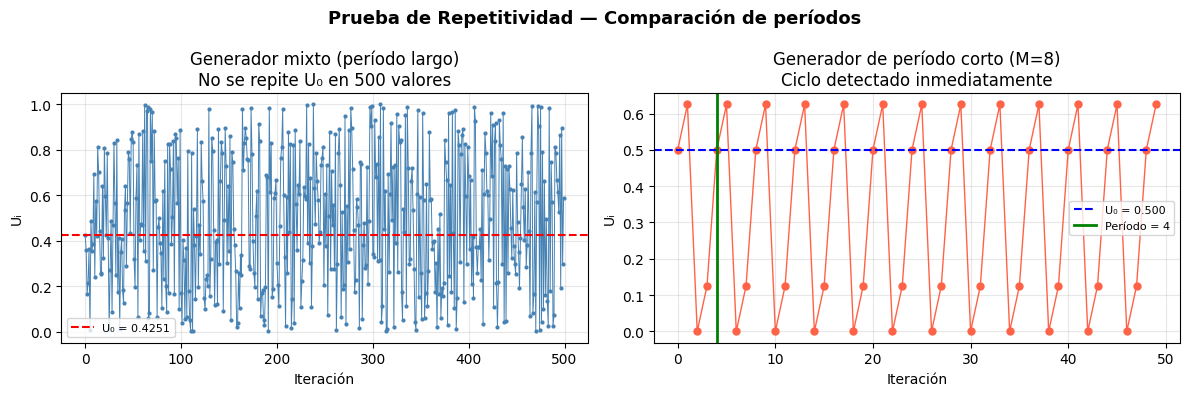

In [24]:
def prueba_repetitividad(us, tolerancia=1e-10):
    """
    Prueba de repetitividad: busca la primera reaparición del valor inicial
    en la secuencia, estimando el período del generador.
    
    us        : secuencia de números en [0,1)
    tolerancia: margen de igualdad para números flotantes
    """
    N = len(us)
    u0 = us[0]
    periodo_detectado = None
    
    for k in range(1, N):
        if abs(us[k] - u0) < tolerancia:
            periodo_detectado = k
            break
    
    return periodo_detectado, N

# Aplicamos a las tres variantes congruenciales 
secuencias_rep = [
    ("Multiplicativo", congruencial_multiplicativo(s0, a, M, 5000)),
    ("Aditivo",        congruencial_aditivo(s0, c, M, 5000)),
    ("Mixto",          congruencial_mixto(s0, a, c, M, 5000)),
]

print(f"{'Método':<20} {'Período detectado':>20} {'N muestras':>12} {'Ciclo en muestra?':>20}")
print("-" * 75)
for nombre, us in secuencias_rep:
    periodo, N = prueba_repetitividad(us)
    if periodo is None:
        print(f"{nombre:<20} {'No detectado (K >> N)':>20} {N:>12} {'NO (bueno)':>20}")
    else:
        print(f"{nombre:<20} {periodo:>20} {N:>12} {'SÍ (malo)':>20}")

# Demostración con un generador de período corto
print("\n--- Demostración con generador de período CORTO (a=3, c=1, M=8) ---")
us_corto = congruencial_mixto(1, 3, 1, 8, 50)
periodo_corto, _ = prueba_repetitividad(us_corto, tolerancia=1e-10)
print(f"Secuencia: {[round(u,3) for u in us_corto[:20]]}")
print(f"Período detectado en posición: {periodo_corto}")
print(f"Módulo M=8 → período máximo teórico = 8")

# Visualización comparativa entre generador de período largo y corto
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Generador de período largo — no hay repetición visible
us_largo = np.array(congruencial_mixto(s0, a, c, M, 500))
axes[0].plot(us_largo, 'o-', markersize=2, lw=0.7, color='steelblue')
axes[0].axhline(us_largo[0], color='red', lw=1.5, linestyle='--',
                label=f'U₀ = {us_largo[0]:.4f}')
axes[0].set_title('Generador mixto (período largo)\nNo se repite U₀ en 500 valores')
axes[0].set_xlabel('Iteración'); axes[0].set_ylabel('Uᵢ')
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

# Generador de período corto — ciclo visible
us_c = np.array(congruencial_mixto(1, 3, 1, 8, 50))
axes[1].plot(us_c, 'o-', markersize=5, lw=1, color='tomato')
axes[1].axhline(us_c[0], color='blue', lw=1.5, linestyle='--',
                label=f'U₀ = {us_c[0]:.3f}')
if periodo_corto:
    axes[1].axvline(periodo_corto, color='green', lw=2,
                    label=f'Período = {periodo_corto}')
axes[1].set_title('Generador de período corto (M=8)\nCiclo detectado inmediatamente')
axes[1].set_xlabel('Iteración'); axes[1].set_ylabel('Uᵢ')
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

plt.suptitle('Prueba de Repetitividad — Comparación de períodos',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### 4.6 Prueba de Uniformidad de los Dígitos

**Descripción:** convierte cada número $U_i$ en sus $d$ primeros dígitos decimales
y verifica que cada dígito (0–9) aparezca con frecuencia $N/10$.

**Propiedad verificada:** que los dígitos de los números pseudoaleatorios estén uniformemente distribuidos.


Método               χ² estadístico   χ² crítico    p-valor     Rechaza?
------------------------------------------------------------------------
Multiplicativo               5.9840      16.9190     0.7415           NO
Aditivo                  45000.0000      16.9190     0.0000           SÍ
Mixto                        8.5240      16.9190     0.4823           NO


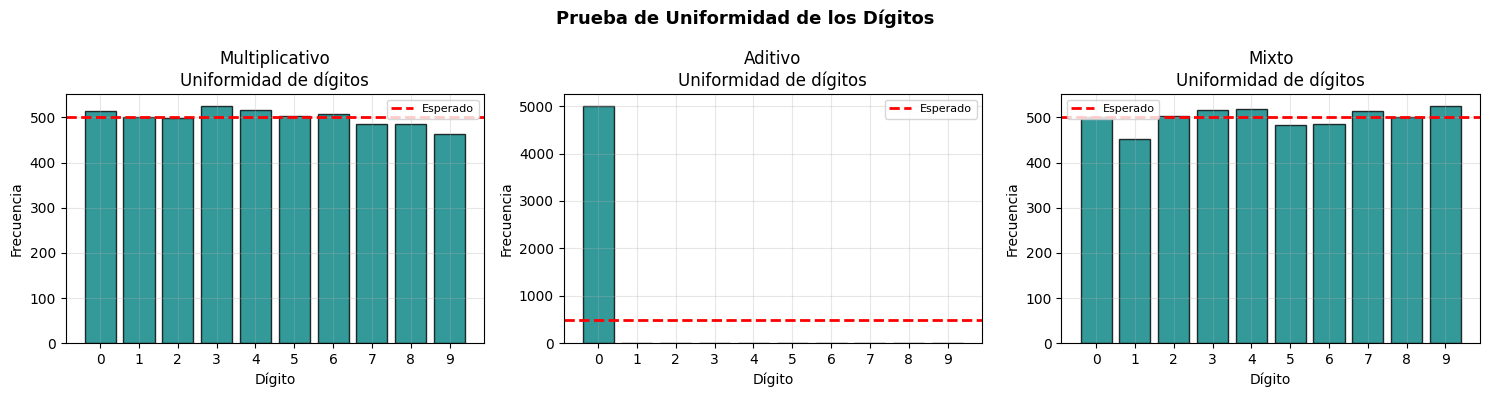

In [26]:
def prueba_uniformidad_digitos(us, d=1, alpha=0.05):
    """
    Prueba de uniformidad del primer dígito decimal de cada U_i.
    d=1 analiza el primer decimal (dígito en posición de décimas).
    """
    digitos = np.floor(np.array(us) * 10).astype(int)
    digitos = np.clip(digitos, 0, 9)  
    N = len(us)
    E = N / 10
    obs = np.bincount(digitos, minlength=10)
    chi2_stat = np.sum((obs - E)**2 / E)
    chi2_crit = chi2.ppf(1 - alpha, df=9)
    p_valor = 1 - chi2.cdf(chi2_stat, df=9)
    rechaza = chi2_stat > chi2_crit
    return chi2_stat, chi2_crit, p_valor, rechaza, obs

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
print(f"{'Método':<18} {'χ² estadístico':>16} {'χ² crítico':>12} {'p-valor':>10} {'Rechaza?':>12}")
print("-" * 72)
for ax, (nombre, us) in zip(axes, secuencias):
    stat, crit, pval, rec, obs = prueba_uniformidad_digitos(us)
    print(f"{nombre:<18} {stat:>16.4f} {crit:>12.4f} {pval:>10.4f} {'SÍ' if rec else 'NO':>12}")
    ax.bar(range(10), obs, color='teal', edgecolor='black', alpha=0.8)
    ax.axhline(len(us)/10, color='red', lw=2, linestyle='--', label='Esperado')
    ax.set_title(f'{nombre}\nUniformidad de dígitos')
    ax.set_xlabel('Dígito'); ax.set_ylabel('Frecuencia'); ax.legend(fontsize=8)
    ax.set_xticks(range(10))

plt.suptitle('Prueba de Uniformidad de los Dígitos', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### 4.7 Prueba de Distancia

**Descripción:** mide la distancia mínima entre pares de puntos $(U_i, U_{i+1})$
en el cuadrado unitario $[0,1]^2$ y verifica que se distribuya como se esperaría
bajo independencia uniforme.

Alternativamente, una versión unidimensional: se calcula la distancia entre cada
valor $U_i$ y su vecino más cercano en la secuencia ordenada.

**Propiedad verificada:** estructura espacial de la secuencia — detecta agrupamiento o separación anormal de puntos.


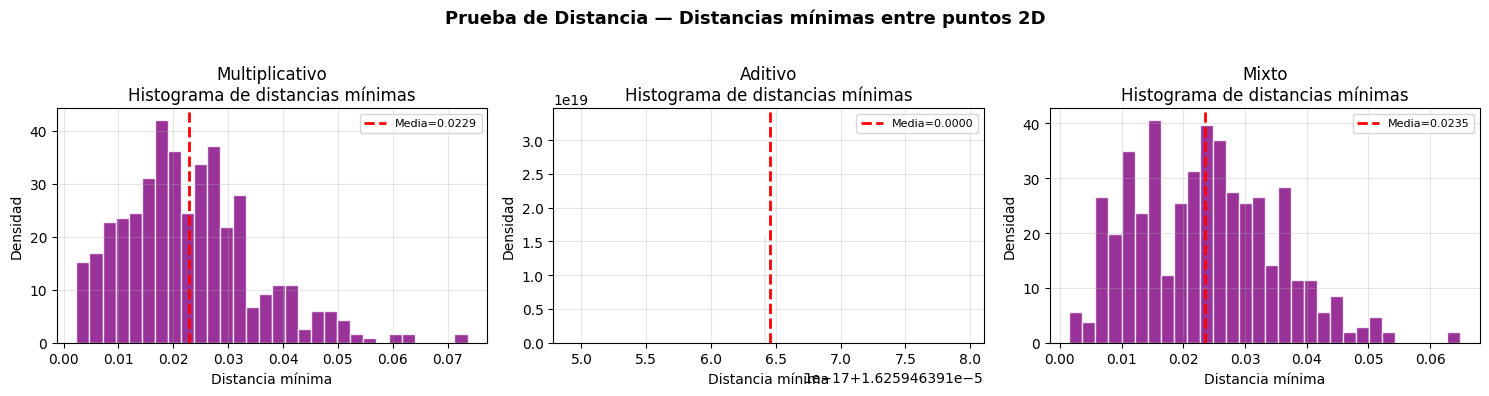

In [27]:
def prueba_distancia(us, alpha=0.05):
    """
    Prueba de distancia mínima entre pares consecutivos en [0,1]^2.
    Toma pares (U_{2i}, U_{2i+1}) como coordenadas de puntos en el plano.
    Bajo uniformidad e independencia, la distancia al vecino más cercano
    sigue aproximadamente una distribución que se puede testear.
    """
    u = np.array(us)
    # Formamos puntos 2D con pares consecutivos
    n_pares = len(u) // 2
    puntos = u[:2*n_pares].reshape(n_pares, 2)
    # Calcular¿mos las distancias mínimas 
    distancias = []
    muestra = puntos[:500]  
    for i in range(len(muestra)):
        dists = np.sqrt(np.sum((muestra - muestra[i])**2, axis=1))
        dists[i] = np.inf  # excluir distancia a sí mismo
        distancias.append(np.min(dists))
    return np.array(distancias)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (nombre, us) in zip(axes, secuencias):
    dists = prueba_distancia(us)
    ax.hist(dists, bins=30, density=True, color='purple', edgecolor='white', alpha=0.8)
    ax.set_title(f'{nombre}\nHistograma de distancias mínimas')
    ax.set_xlabel('Distancia mínima'); ax.set_ylabel('Densidad')
    ax.axvline(np.mean(dists), color='red', lw=2, linestyle='--', label=f'Media={np.mean(dists):.4f}')
    ax.legend(fontsize=8)

plt.suptitle('Prueba de Distancia — Distancias mínimas entre puntos 2D', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


---
## Punto 5 — Generación de variables aleatorias a partir de U[0,1]

### Formalismo: Método de la Transformada Inversa

**Idea central:** si $U \sim U[0,1]$ y $F$ es la CDF de la distribución que queremos generar,
entonces la variable $X = F^{-1}(U)$ tiene distribución $F$.

**Demostración:**
$$P(X \leq x) = P(F^{-1}(U) \leq x) = P(U \leq F(x)) = F(x) \checkmark$$

**Algoritmo:**
1. Generar $U \sim U[0,1]$.
2. Calcular $X = F^{-1}(U)$.

Esto funciona siempre que $F^{-1}$ (la función cuantil) exista y sea computable.


### 5.1 Transformada inversa — Distribución Exponencial

$$F(x) = 1 - e^{-\lambda x} \implies F^{-1}(u) = -\frac{\ln(1-u)}{\lambda}$$

Como $1-U \sim U[0,1]$ también, se simplifica a:

$$X = -\frac{\ln(U)}{\lambda}$$


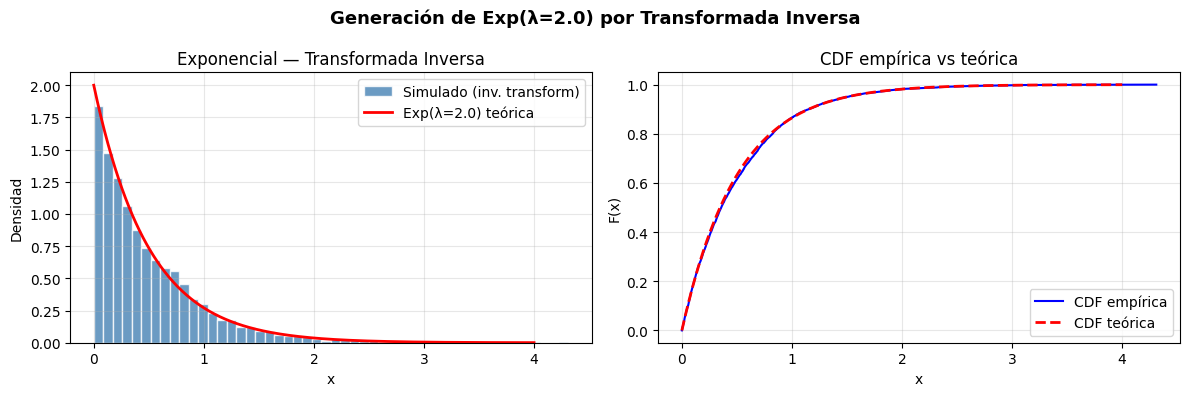

Media simulada:    0.5099  (teórica: 0.5000)
Varianza simulada: 0.2538  (teórica: 0.2500)


In [28]:
def generar_exponencial_inv(lam, n, semilla=42):
    """Genera n valores Exp(lambda) por transformada inversa usando LCG propio."""
    us = congruencial_mixto(semilla, 16807, 12345, 2**31 - 1, n)
    us = np.clip(us, 1e-10, 1 - 1e-10)  # evitar log(0)
    return -np.log(us) / lam

lam = 2.0
N   = 5000
X_exp = generar_exponencial_inv(lam, N)

x = np.linspace(0, 4, 500)
pdf_teo = lam * np.exp(-lam * x)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(X_exp, bins=50, density=True, color='steelblue', edgecolor='white',
             alpha=0.8, label='Simulado (inv. transform)')
axes[0].plot(x, pdf_teo, 'r-', lw=2, label=f'Exp(λ={lam}) teórica')
axes[0].set_title('Exponencial — Transformada Inversa')
axes[0].set_xlabel('x'); axes[0].set_ylabel('Densidad'); axes[0].legend()

axes[1].plot(np.sort(X_exp), np.linspace(0, 1, N), 'b-', lw=1.5, label='CDF empírica')
axes[1].plot(x, 1 - np.exp(-lam * x), 'r--', lw=2, label='CDF teórica')
axes[1].set_title('CDF empírica vs teórica')
axes[1].set_xlabel('x'); axes[1].set_ylabel('F(x)'); axes[1].legend()

plt.suptitle(f'Generación de Exp(λ={lam}) por Transformada Inversa', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Media simulada:    {np.mean(X_exp):.4f}  (teórica: {1/lam:.4f})")
print(f"Varianza simulada: {np.var(X_exp):.4f}  (teórica: {1/lam**2:.4f})")


### 5.2 Transformada inversa — Distribución Uniforme (a, b)

$$F(x) = \frac{x-a}{b-a} \implies F^{-1}(u) = a + (b-a) \cdot u$$


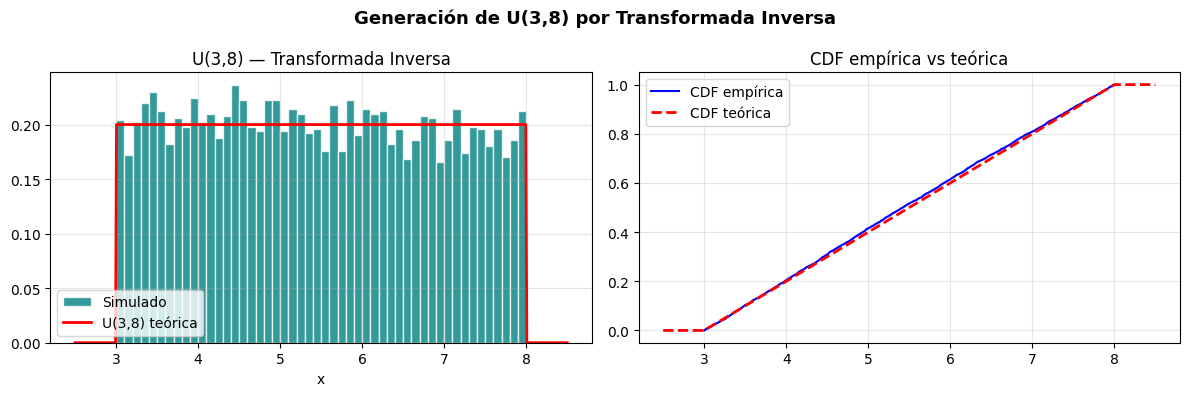

Media simulada:    5.4564  (teórica: 5.5000)
Varianza simulada: 2.0578  (teórica: 2.0833)


In [29]:
def generar_uniforme_inv(a, b, n, semilla=99):
    """Genera n valores U(a,b) por transformada inversa."""
    us = congruencial_mixto(semilla, 16807, 12345, 2**31 - 1, n)
    return a + (b - a) * np.array(us)

a, b = 3, 8
X_unif = generar_uniforme_inv(a, b, N)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
x_plot = np.linspace(a - 0.5, b + 0.5, 500)
pdf_teo = np.where((x_plot >= a) & (x_plot <= b), 1/(b-a), 0)

axes[0].hist(X_unif, bins=50, density=True, color='teal', edgecolor='white',
             alpha=0.8, label='Simulado')
axes[0].plot(x_plot, pdf_teo, 'r-', lw=2, label=f'U({a},{b}) teórica')
axes[0].set_title(f'U({a},{b}) — Transformada Inversa')
axes[0].set_xlabel('x'); axes[0].legend()

axes[1].plot(np.sort(X_unif), np.linspace(0, 1, N), 'b-', lw=1.5, label='CDF empírica')
cdf_teo = np.clip((x_plot - a)/(b - a), 0, 1)
axes[1].plot(x_plot, cdf_teo, 'r--', lw=2, label='CDF teórica')
axes[1].set_title('CDF empírica vs teórica'); axes[1].legend()

plt.suptitle(f'Generación de U({a},{b}) por Transformada Inversa', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Media simulada:    {np.mean(X_unif):.4f}  (teórica: {(a+b)/2:.4f})")
print(f"Varianza simulada: {np.var(X_unif):.4f}  (teórica: {(b-a)**2/12:.4f})")


### 5.3 Transformada inversa — Distribución Discreta (Bernoulli y Poisson)

Para distribuciones discretas la inversa se implementa recorriendo la CDF hasta encontrar el primer valor $x_k$ tal que $F(x_k) \geq U$.


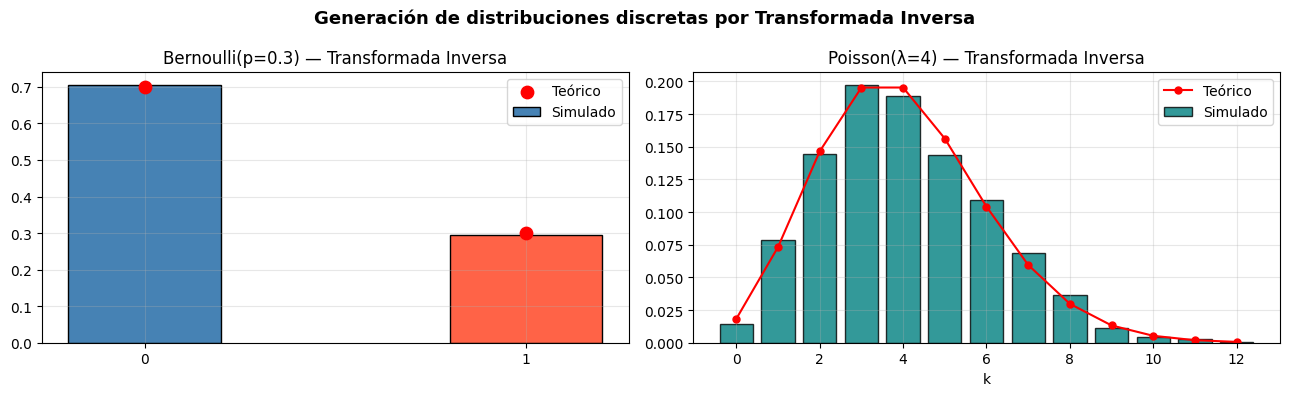

Bernoulli — Media simulada: 0.2942  (teórica: 0.3000)
Poisson   — Media simulada: 4.0370  (teórica: 4.0000)
Poisson   — Var  simulada:  4.0756  (teórica: 4.0000)


In [30]:
def generar_bernoulli_inv(p, n, semilla=77):
    """Genera n valores Bernoulli(p) por transformada inversa."""
    us = congruencial_mixto(semilla, 16807, 12345, 2**31 - 1, n)
    return (np.array(us) < p).astype(int)

def generar_poisson_inv(lam, n, semilla=55):
    """Genera n valores Poisson(lambda) por transformada inversa."""
    us = congruencial_mixto(semilla, 16807, 12345, 2**31 - 1, n)
    resultados = []
    for u in us:
        k = 0
        F = np.exp(-lam)   # P(X=0)
        acum = F
        while acum < u:
            k += 1
            F *= lam / k   # P(X=k) = P(X=k-1) * lambda/k
            acum += F
        resultados.append(k)
    return np.array(resultados)

# Bernoulli
p = 0.3
X_bern = generar_bernoulli_inv(p, N)

# Poisson 
lam_p = 4
X_pois = generar_poisson_inv(lam_p, 2000)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Bernoulli
vals, cnts = np.unique(X_bern, return_counts=True)
freqs = cnts / N
axes[0].bar(vals, freqs, color=['steelblue', 'tomato'], width=0.4, edgecolor='black', label='Simulado')
axes[0].scatter([0, 1], [1-p, p], color='red', zorder=5, s=80, label='Teórico')
axes[0].set_title(f'Bernoulli(p={p}) — Transformada Inversa')
axes[0].set_xticks([0, 1]); axes[0].legend()

# Poisson
k_vals = np.arange(0, int(lam_p * 3) + 1)
axes[1].bar(k_vals, [np.sum(X_pois == k)/len(X_pois) for k in k_vals],
            color='teal', edgecolor='black', alpha=0.8, label='Simulado')
axes[1].plot(k_vals, stats.poisson.pmf(k_vals, lam_p), 'ro-', lw=1.5, markersize=5, label='Teórico')
axes[1].set_title(f'Poisson(λ={lam_p}) — Transformada Inversa')
axes[1].set_xlabel('k'); axes[1].legend()

plt.suptitle('Generación de distribuciones discretas por Transformada Inversa', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Bernoulli — Media simulada: {np.mean(X_bern):.4f}  (teórica: {p:.4f})")
print(f"Poisson   — Media simulada: {np.mean(X_pois):.4f}  (teórica: {lam_p:.4f})")
print(f"Poisson   — Var  simulada:  {np.var(X_pois):.4f}  (teórica: {lam_p:.4f})")


### 5.4 Transformada inversa — Distribución Triangular (fórmula exacta)

A diferencia de la implementación con `scipy` del Punto 1, aquí derivamos el 
generador **desde cero** usando la transformada inversa, siguiendo la ecuación (30) 
del material de referencia de la cátedra.

**Fórmula general de la PDF triangular** con mínimo $a$, moda $b$, máximo $c$:

$$f(x) = \begin{cases}
\dfrac{2(x-a)}{(c-a)(b-a)} & a \leq x < b \\[8pt]
\dfrac{2(c-x)}{(c-a)(c-b)} & b \leq x \leq c
\end{cases}$$

**Aplicando la transformada inversa** se obtiene (ec. 30 del material):

$$X = \begin{cases}
a + \sqrt{(b-a)(c-a) \cdot R} & 0 \leq R < \dfrac{b-a}{c-a} \\[8pt]
b + \sqrt{[(c-a)R - (b-a)](c-b)} & \dfrac{b-a}{c-a} \leq R \leq 1
\end{cases}$$

donde $R \sim U[0,1]$.

**Punto de corte:** $R_c = \dfrac{b-a}{c-a}$ separa los dos tramos de la inversa.


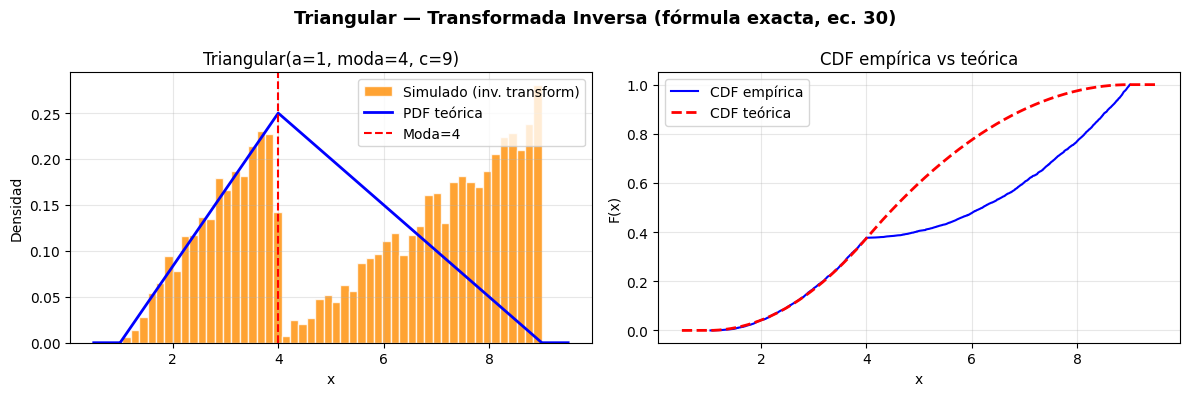

Media simulada:    5.7021  (teórica: 4.6667)
Varianza simulada: 5.4832  (teórica: 2.7222)
Punto de corte Rc: 0.3750


In [31]:

def generar_triangular_inv(a, b, c, n, semilla=33):
    """
    Genera n valores con distribución Triangular(a, b, c) por transformada inversa.
    a: mínimo, b: moda, c: máximo
    Fórmula según ec. (30) del material de cátedra.
    """
    # Acá generamos U[0,1] con nuestro LCG
    us = congruencial_mixto(semilla, 16807, 12345, 2**31 - 1, n)
    us = np.array(us)
    
    Rc = (b - a) / (c - a)   
    
    X = np.where(
        us < Rc,
        a + np.sqrt((b - a) * (c - a) * us),                          # tramo 1
        b + np.sqrt(((c - a) * us - (b - a)) * (c - b))               # tramo 2
    )
    return X

# Parámetros: mínimo=1, moda=4, máximo=9 (mismo que Punto 1)
a_t, b_t, c_t = 1, 4, 9
N = 5000
X_tri = generar_triangular_inv(a_t, b_t, c_t, N)

# Comparamos con la PDF teórica
from scipy.stats import triang
loc = a_t
scale = c_t - a_t
c_norm = (b_t - a_t) / (c_t - a_t)
x_plot = np.linspace(a_t - 0.5, c_t + 0.5, 500)
rv = triang(c_norm, loc=loc, scale=scale)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(X_tri, bins=50, density=True, color='darkorange', edgecolor='white',
             alpha=0.8, label='Simulado (inv. transform)')
axes[0].plot(x_plot, rv.pdf(x_plot), 'b-', lw=2, label='PDF teórica')
axes[0].axvline(b_t, color='red', linestyle='--', lw=1.5, label=f'Moda={b_t}')
axes[0].set_title(f'Triangular(a={a_t}, moda={b_t}, c={c_t})')
axes[0].set_xlabel('x'); axes[0].set_ylabel('Densidad'); axes[0].legend()

axes[1].plot(np.sort(X_tri), np.linspace(0, 1, N), 'b-', lw=1.5, label='CDF empírica')
axes[1].plot(x_plot, rv.cdf(x_plot), 'r--', lw=2, label='CDF teórica')
axes[1].set_title('CDF empírica vs teórica')
axes[1].set_xlabel('x'); axes[1].set_ylabel('F(x)'); axes[1].legend()

plt.suptitle('Triangular — Transformada Inversa (fórmula exacta, ec. 30)', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

media_teo = (a_t + b_t + c_t) / 3
varianza_teo = (a_t**2 + b_t**2 + c_t**2 - a_t*b_t - a_t*c_t - b_t*c_t) / 18
print(f"Media simulada:    {np.mean(X_tri):.4f}  (teórica: {media_teo:.4f})")
print(f"Varianza simulada: {np.var(X_tri):.4f}  (teórica: {varianza_teo:.4f})")
print(f"Punto de corte Rc: {(b_t - a_t)/(c_t - a_t):.4f}")
